In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


Importing libraries

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.3f}".format)

sns.set_theme(
    style="whitegrid",
    palette="deep"
)

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
DATA_PATH = Path(
    "/content/drive/MyDrive/HeadsUpProject/data/"
    "DataCoSupplyChainDataset.csv"
)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}"
    )

print("Dataset found:")
print(DATA_PATH)

Dataset found:
/content/drive/MyDrive/HeadsUpProject/data/DataCoSupplyChainDataset.csv


In [4]:
raw_df = pd.read_csv(
    DATA_PATH,
    encoding="latin-1",
    low_memory=False
)

print("Dataset loaded successfully.")
print(f"Rows: {raw_df.shape[0]:,}")
print(f"Columns: {raw_df.shape[1]}")

display(raw_df.head())

Dataset loaded successfully.
Rows: 180,519
Columns: 53


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250,314.640,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.000,2,Fitness,18.251,-66.037,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110,0.040,180517,327.750,0.290,1,327.750,314.640,91.250,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.090,311.360,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.000,2,Fitness,18.279,-66.037,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.390,0.050,179254,327.750,-0.800,1,327.750,311.360,-249.090,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.780,309.720,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,"95,125.000",2,Fitness,37.292,-121.881,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030,0.060,179253,327.750,-0.800,1,327.750,309.720,-247.780,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860,304.810,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,"90,027.000",2,Fitness,34.126,-118.291,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940,0.070,179252,327.750,0.080,1,327.750,304.810,22.860,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210,298.250,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.000,2,Fitness,18.254,-66.037,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500,0.090,179251,327.750,0.450,1,327.750,298.250,134.210,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750,0,1/15/2018 11:24,Standard Class


In [5]:
required_columns = {
    "Order Id",
    "Order Item Id",
    "Late_delivery_risk",
    "Delivery Status",
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "order date (DateOrders)",
    "shipping date (DateOrders)",
    "Shipping Mode"
}

missing_required_columns = (
    required_columns - set(raw_df.columns)
)

if missing_required_columns:
    raise ValueError(
        "Required columns are missing: "
        f"{sorted(missing_required_columns)}"
    )

print("Required-column validation passed.")

Required-column validation passed.


Basic Dataset Summary

In [6]:
required_columns = {
    "Order Id",
    "Order Item Id",
    "Late_delivery_risk",
    "Delivery Status",
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "order date (DateOrders)",
    "shipping date (DateOrders)",
    "Shipping Mode"
}

missing_required_columns = (
    required_columns - set(raw_df.columns)
)

if missing_required_columns:
    raise ValueError(
        "Required columns are missing: "
        f"{sorted(missing_required_columns)}"
    )

print("Required-column validation passed.")

Required-column validation passed.


In [7]:
dataset_summary = pd.DataFrame({
    "metric": [
        "Raw rows",
        "Columns",
        "Unique orders",
        "Unique order items",
        "Exact duplicate rows",
        "Total missing cells"
    ],
    "value": [
        raw_df.shape[0],
        raw_df.shape[1],
        raw_df["Order Id"].nunique(),
        raw_df["Order Item Id"].nunique(),
        raw_df.duplicated().sum(),
        raw_df.isna().sum().sum()
    ]
})

display(dataset_summary)

,metric,value
0,Raw rows,180519
1,Columns,53
2,Unique orders,65752
3,Unique order items,180519
4,Exact duplicate rows,0
5,Total missing cells,336209


Chema report

In [8]:
schema_report = pd.DataFrame({
    "column": raw_df.columns,
    "data_type": raw_df.dtypes.astype(str).values,
    "non_missing_count": raw_df.notna().sum().values,
    "missing_count": raw_df.isna().sum().values,
    "unique_value_count": raw_df.nunique(
        dropna=False
    ).values
})

display(schema_report)

,column,data_type,non_missing_count,missing_count,unique_value_count
0,Type,object,180519,0,4
1,Days for shipping (real),int64,180519,0,7
2,Days for shipment (scheduled),int64,180519,0,4
3,Benefit per order,float64,180519,0,21998
4,Sales per customer,float64,180519,0,2927
5,Delivery Status,object,180519,0,4
6,Late_delivery_risk,int64,180519,0,2
7,Category Id,int64,180519,0,51
8,Category Name,object,180519,0,50
9,Customer City,object,180519,0,563


Missing Value report

In [9]:
missing_report = pd.DataFrame({
    "column": raw_df.columns,
    "missing_count": raw_df.isna().sum().values,
    "missing_percentage": (
        raw_df.isna().mean().values * 100
    )
})

missing_report = (
    missing_report
    .query("missing_count > 0")
    .sort_values(
        "missing_percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

display(missing_report)

,column,missing_count,missing_percentage
0,Product Description,180519,100.000
1,Order Zipcode,155679,86.240
2,Customer Lname,8,0.004
3,Customer Zipcode,3,0.002


In [10]:
missing_report = pd.DataFrame({
    "column": raw_df.columns,
    "missing_count": raw_df.isna().sum().values,
    "missing_percentage": (
        raw_df.isna().mean().values * 100
    )
})

missing_report = (
    missing_report
    .query("missing_count > 0")
    .sort_values(
        "missing_percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

display(missing_report)

,column,missing_count,missing_percentage
0,Product Description,180519,100.000
1,Order Zipcode,155679,86.240
2,Customer Lname,8,0.004
3,Customer Zipcode,3,0.002


Raw Target Distribution

In [11]:
TARGET = "Late_delivery_risk"

raw_target_report = (
    raw_df[TARGET]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("target")
    .reset_index(name="row_count")
)

raw_target_report["percentage"] = (
    raw_target_report["row_count"]
    / len(raw_df)
    * 100
)

display(raw_target_report)

,target,row_count,percentage
0,0,81542,45.171
1,1,98977,54.829


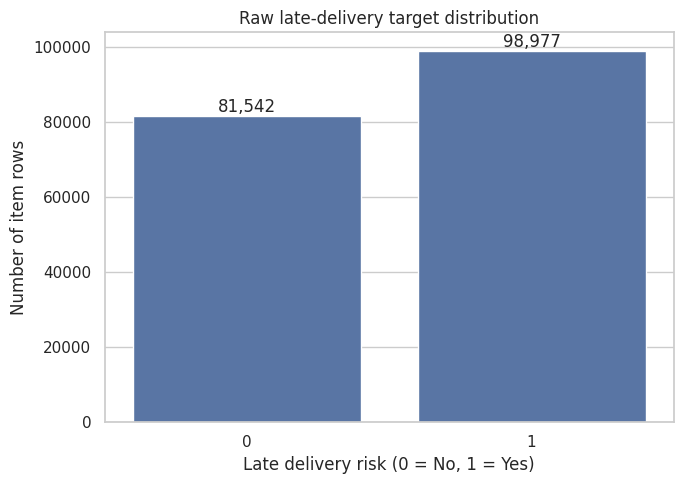

In [13]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=raw_df,
    x=TARGET,
    color="#4C72B0"
)

plt.title("Raw late-delivery target distribution")
plt.xlabel("Late delivery risk (0 = No, 1 = Yes)")
plt.ylabel("Number of item rows")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="{:,.0f}"
    )

plt.tight_layout()
plt.show()

Delivery Status Vs Target

In [14]:
target_status_check = pd.crosstab(
    raw_df["Delivery Status"],
    raw_df["Late_delivery_risk"],
    margins=True,
    margins_name="Total"
)

display(target_status_check)

Late_delivery_risk,0,1,Total
Delivery Status,,,
Advance shipping,41592,0,41592
Late delivery,0,98977,98977
Shipping canceled,7754,0,7754
Shipping on time,32196,0,32196
Total,81542,98977,180519


### Target definition decision

The cross-tabulation between `Delivery Status` and
`Late_delivery_risk` showed that:

- Late-delivery records are coded as `Late_delivery_risk = 1`.
- Advance-shipping, on-time and cancelled records are coded as
  `Late_delivery_risk = 0`.

The source dataset therefore treats cancellation as a non-late outcome,
although the initial proposal wording included cancellation in the
positive class.

Following team review, the project will preserve the supplied
`Late_delivery_risk` target without relabeling:

- `1` = Late delivery
- `0` = Non-late outcome, including cancelled shipments as coded in
  the source dataset

The primary model predicts late delivery rather than general delivery
failure. `Delivery Status` is retained only for EDA validation and is
excluded from model features because it is post-outcome information
that would cause data leakage.

In [15]:
items_per_order = (
    raw_df
    .groupby("Order Id")
    .size()
    .rename("item_rows")
)

display(
    items_per_order
    .describe()
    .to_frame("value")
)

,value
count,"65,752.000"
mean,2.745
std,1.478
min,1.000
25%,1.000
50%,3.000
75%,4.000
max,5.000


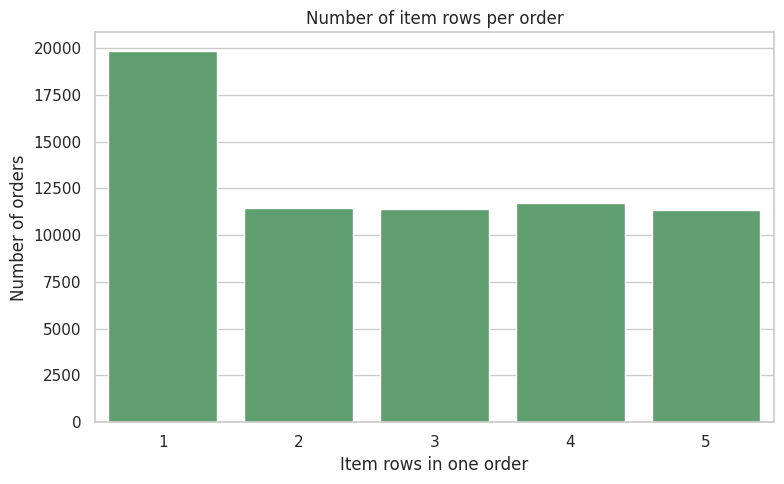

In [16]:
items_distribution = (
    items_per_order
    .value_counts()
    .sort_index()
    .rename_axis("items_per_order")
    .reset_index(name="number_of_orders")
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=items_distribution,
    x="items_per_order",
    y="number_of_orders",
    color="#55A868"
)

plt.title("Number of item rows per order")
plt.xlabel("Item rows in one order")
plt.ylabel("Number of orders")

plt.tight_layout()
plt.show()

In [17]:
working_df = raw_df.copy(deep=True)

working_df["order_date"] = pd.to_datetime(
    working_df["order date (DateOrders)"],
    errors="coerce"
)

working_df["shipping_date"] = pd.to_datetime(
    working_df["shipping date (DateOrders)"],
    errors="coerce"
)

print(
    "Invalid order dates:",
    working_df["order_date"].isna().sum()
)

print(
    "Invalid shipping dates:",
    working_df["shipping_date"].isna().sum()
)

print(
    "Order-date range:",
    working_df["order_date"].min(),
    "to",
    working_df["order_date"].max()
)

Invalid order dates: 0
Invalid shipping dates: 0
Order-date range: 2015-01-01 00:00:00 to 2018-01-31 23:38:00


Order-level consistency check

In [18]:
order_level_columns = [
    "Late_delivery_risk",
    "Delivery Status",
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Shipping Mode",
    "Type",
    "Customer Id",
    "Customer Segment",
    "Market",
    "Order Region",
    "Order Country",
    "Order State",
    "order date (DateOrders)",
    "shipping date (DateOrders)"
]

consistency_results = []

for column in order_level_columns:
    conflicting_orders = (
        working_df
        .groupby("Order Id")[column]
        .nunique(dropna=False)
        .gt(1)
        .sum()
    )

    consistency_results.append({
        "column": column,
        "orders_with_conflicts": conflicting_orders
    })

consistency_report = pd.DataFrame(
    consistency_results
)

display(consistency_report)

,column,orders_with_conflicts
0,Late_delivery_risk,0
1,Delivery Status,0
2,Days for shipping (real),0
3,Days for shipment (scheduled),0
4,Shipping Mode,0
5,Type,0
6,Customer Id,0
7,Customer Segment,0
8,Market,0
9,Order Region,0


Aggregating Item rows into Order rows

In [19]:
orders = (
    working_df
    .groupby("Order Id", as_index=False)
    .agg(
        target=(
            "Late_delivery_risk",
            "first"
        ),

        delivery_status=(
            "Delivery Status",
            "first"
        ),

        actual_shipping_days=(
            "Days for shipping (real)",
            "first"
        ),

        scheduled_shipping_days=(
            "Days for shipment (scheduled)",
            "first"
        ),

        order_date=(
            "order_date",
            "first"
        ),

        shipping_mode=(
            "Shipping Mode",
            "first"
        ),

        payment_type=(
            "Type",
            "first"
        ),

        customer_segment=(
            "Customer Segment",
            "first"
        ),

        market=(
            "Market",
            "first"
        ),

        order_region=(
            "Order Region",
            "first"
        ),

        order_country=(
            "Order Country",
            "first"
        ),

        order_state=(
            "Order State",
            "first"
        ),

        total_quantity=(
            "Order Item Quantity",
            "sum"
        ),

        gross_sales=(
            "Sales",
            "sum"
        ),

        total_order_value=(
            "Order Item Total",
            "sum"
        ),

        total_discount=(
            "Order Item Discount",
            "sum"
        ),

        total_profit=(
            "Benefit per order",
            "sum"
        ),

        item_rows=(
            "Order Item Id",
            "count"
        ),

        unique_products=(
            "Product Card Id",
            "nunique"
        ),

        unique_categories=(
            "Category Id",
            "nunique"
        )
    )
)

print("Raw item-level shape:", raw_df.shape)
print("Order-level shape:", orders.shape)

display(orders.head())

Raw item-level shape: (180519, 53)
Order-level shape: (65752, 21)


,Order Id,target,delivery_status,actual_shipping_days,scheduled_shipping_days,order_date,shipping_mode,payment_type,customer_segment,market,order_region,order_country,order_state,total_quantity,gross_sales,total_order_value,total_discount,total_profit,item_rows,unique_products,unique_categories
0,1,0,Advance shipping,2,4,2015-01-01 00:00:00,Standard Class,CASH,Consumer,LATAM,Central America,México,Distrito Federal,1,299.980,239.980,60.000,88.790,1,1,1
1,2,0,Advance shipping,3,4,2015-01-01 00:21:00,Standard Class,PAYMENT,Consumer,LATAM,South America,Colombia,Risaralda,7,579.980,529.380,50.600,195.900,3,3,3
2,4,1,Late delivery,5,4,2015-01-01 01:03:00,Standard Class,CASH,Home Office,LATAM,South America,Colombia,Risaralda,14,699.850,620.870,78.980,124.090,4,4,4
3,5,1,Late delivery,6,4,2015-01-01 01:24:00,Standard Class,DEBIT,Consumer,LATAM,South America,Colombia,Risaralda,10,"1,129.860",987.070,142.790,390.090,5,4,4
4,7,1,Late delivery,3,2,2015-01-01 02:06:00,Second Class,DEBIT,Consumer,LATAM,South America,Brasil,São Paulo,7,579.920,525.520,54.400,203.930,3,3,3


In [20]:
orders["order_year"] = (
    orders["order_date"].dt.year
)

orders["order_month"] = (
    orders["order_date"].dt.month
)

orders["order_day_of_week"] = (
    orders["order_date"].dt.dayofweek
)

orders["order_hour"] = (
    orders["order_date"].dt.hour
)

orders["is_weekend"] = (
    orders["order_day_of_week"]
    .isin([5, 6])
    .astype(int)
)

display(
    orders[
        [
            "order_date",
            "order_year",
            "order_month",
            "order_day_of_week",
            "order_hour",
            "is_weekend"
        ]
    ].head()
)

,order_date,order_year,order_month,order_day_of_week,order_hour,is_weekend
0,2015-01-01 00:00:00,2015,1,3,0,0
1,2015-01-01 00:21:00,2015,1,3,0,0
2,2015-01-01 01:03:00,2015,1,3,1,0
3,2015-01-01 01:24:00,2015,1,3,1,0
4,2015-01-01 02:06:00,2015,1,3,2,0


In [21]:
order_missing_report = pd.DataFrame({
    "column": orders.columns,
    "missing_count": orders.isna().sum().values,
    "missing_percentage": (
        orders.isna().mean().values * 100
    )
})

order_missing_report = (
    order_missing_report
    .query("missing_count > 0")
    .sort_values(
        "missing_percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

if order_missing_report.empty:
    print(
        "No missing values exist in the "
        "selected order-level columns."
    )
else:
    display(order_missing_report)

No missing values exist in the selected order-level columns.


In [22]:
X = orders.drop(
    columns=[
        # Correct answer:
        "target",

        # Identifier, not a predictor:
        "Order Id",

        # Date components have already been extracted:
        "order_date",

        # These are known only after delivery:
        "delivery_status",
        "actual_shipping_days"
    ]
)

y = orders["target"]

print("Feature table shape:", X.shape)
print("Target shape:", y.shape)
print("\nModel features:")

for column in X.columns:
    print(column)

Feature table shape: (65752, 21)
Target shape: (65752,)

Model features:
scheduled_shipping_days
shipping_mode
payment_type
customer_segment
market
order_region
order_country
order_state
total_quantity
gross_sales
total_order_value
total_discount
total_profit
item_rows
unique_products
unique_categories
order_year
order_month
order_day_of_week
order_hour
is_weekend


Splitting

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_temporary, y_train, y_temporary = (
    train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=RANDOM_STATE,
        stratify=y
    )
)

X_validation, X_test, y_validation, y_test = (
    train_test_split(
        X_temporary,
        y_temporary,
        test_size=0.50,
        random_state=RANDOM_STATE,
        stratify=y_temporary
    )
)

print("Dataset split completed.")

Dataset split completed.


In [24]:
split_report = pd.DataFrame({
    "dataset": [
        "Training",
        "Validation",
        "Testing"
    ],

    "rows": [
        len(X_train),
        len(X_validation),
        len(X_test)
    ],

    "percentage_of_total": [
        len(X_train) / len(X) * 100,
        len(X_validation) / len(X) * 100,
        len(X_test) / len(X) * 100
    ],

    "late_rate_percentage": [
        y_train.mean() * 100,
        y_validation.mean() * 100,
        y_test.mean() * 100
    ]
})

display(split_report)

,dataset,rows,percentage_of_total,late_rate_percentage
0,Training,46026,69.999,54.823
1,Validation,9863,15.000,54.831
2,Testing,9863,15.000,54.821


In [25]:
train_eda = X_train.join(
    y_train.rename("target")
)

print("Training EDA shape:", train_eda.shape)

display(train_eda.head())

Training EDA shape: (46026, 22)


,scheduled_shipping_days,shipping_mode,payment_type,customer_segment,market,order_region,order_country,order_state,total_quantity,gross_sales,total_order_value,total_discount,total_profit,item_rows,unique_products,unique_categories,order_year,order_month,order_day_of_week,order_hour,is_weekend,target
57391,4,Standard Class,DEBIT,Home Office,Europe,Southern Europe,España,Islas Baleares,1,129.990,109.190,20.800,30.570,1,1,1,2017,10,6,18,1,0
32808,4,Standard Class,CASH,Consumer,USCA,East of USA,Estados Unidos,Nueva York,4,379.950,356.060,23.900,75.570,3,3,3,2016,7,3,12,0,0
36305,1,First Class,DEBIT,Consumer,Pacific Asia,West Asia,Arabia Saudí,Riad,13,"1,117.890",981.760,136.130,86.280,5,5,5,2016,9,1,13,0,1
27170,2,Second Class,TRANSFER,Corporate,USCA,East of USA,Estados Unidos,Nueva York,1,59.990,50.990,9.000,24.480,1,1,1,2016,4,1,17,0,1
61793,4,Standard Class,DEBIT,Consumer,Pacific Asia,Oceania,Australia,Australia del Sur,1,11.540,10.910,0.630,4.910,1,1,1,2017,12,1,4,0,0


Shipping mode analysis

In [26]:
shipping_mode_summary = (
    train_eda
    .groupby("shipping_mode", as_index=False)
    .agg(
        order_count=("target", "size"),
        late_rate=("target", "mean")
    )
)

shipping_mode_summary["late_rate_percentage"] = (
    shipping_mode_summary["late_rate"] * 100
)

shipping_mode_summary = (
    shipping_mode_summary
    .sort_values(
        "late_rate_percentage",
        ascending=False
    )
)

display(shipping_mode_summary)

,shipping_mode,order_count,late_rate,late_rate_percentage
0,First Class,7063,0.954,95.413
2,Second Class,8931,0.768,76.789
1,Same Day,2446,0.453,45.339
3,Standard Class,27586,0.382,38.161


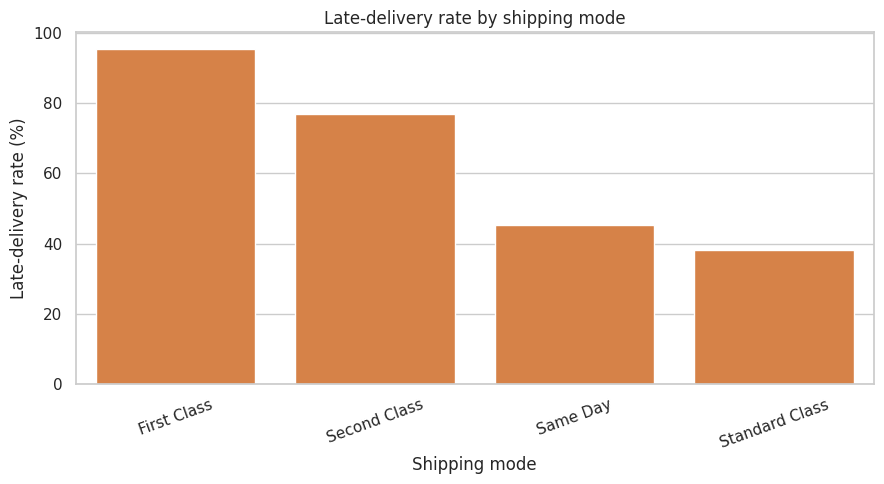

In [27]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=shipping_mode_summary,
    x="shipping_mode",
    y="late_rate_percentage",
    color="#ED7D31"
)

plt.title("Late-delivery rate by shipping mode")
plt.xlabel("Shipping mode")
plt.ylabel("Late-delivery rate (%)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

Market analysis

In [28]:
market_summary = (
    train_eda
    .groupby("market", as_index=False)
    .agg(
        order_count=("target", "size"),
        late_rate=("target", "mean")
    )
)

market_summary["late_rate_percentage"] = (
    market_summary["late_rate"] * 100
)

market_summary = (
    market_summary
    .sort_values(
        "late_rate_percentage",
        ascending=False
    )
)

display(market_summary)

,market,order_count,late_rate,late_rate_percentage
1,Europe,12946,0.552,55.152
3,Pacific Asia,12259,0.551,55.127
4,USCA,6030,0.545,54.511
2,LATAM,12108,0.544,54.435
0,Africa,2683,0.543,54.305


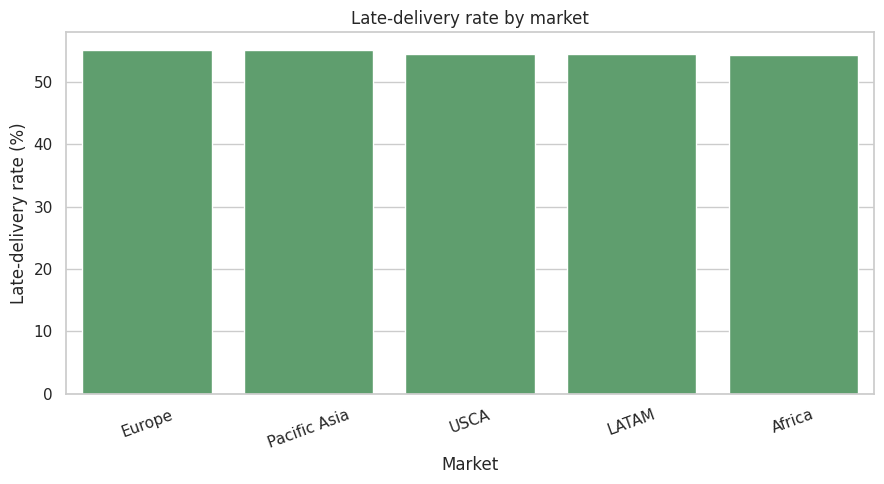

In [29]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=market_summary,
    x="market",
    y="late_rate_percentage",
    color="#55A868"
)

plt.title("Late-delivery rate by market")
plt.xlabel("Market")
plt.ylabel("Late-delivery rate (%)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

Monthly analysis

In [30]:
monthly_summary = (
    train_eda
    .groupby("order_month", as_index=False)
    .agg(
        order_count=("target", "size"),
        late_rate=("target", "mean")
    )
)

monthly_summary["late_rate_percentage"] = (
    monthly_summary["late_rate"] * 100
)

display(monthly_summary)

,order_month,order_count,late_rate,late_rate_percentage
0,1,5208,0.547,54.724
1,2,3371,0.543,54.316
2,3,3732,0.554,55.439
3,4,3657,0.534,53.377
4,5,3734,0.551,55.088
5,6,3537,0.557,55.669
6,7,3698,0.544,54.435
7,8,3731,0.551,55.052
8,9,3565,0.547,54.698
9,10,3964,0.546,54.617


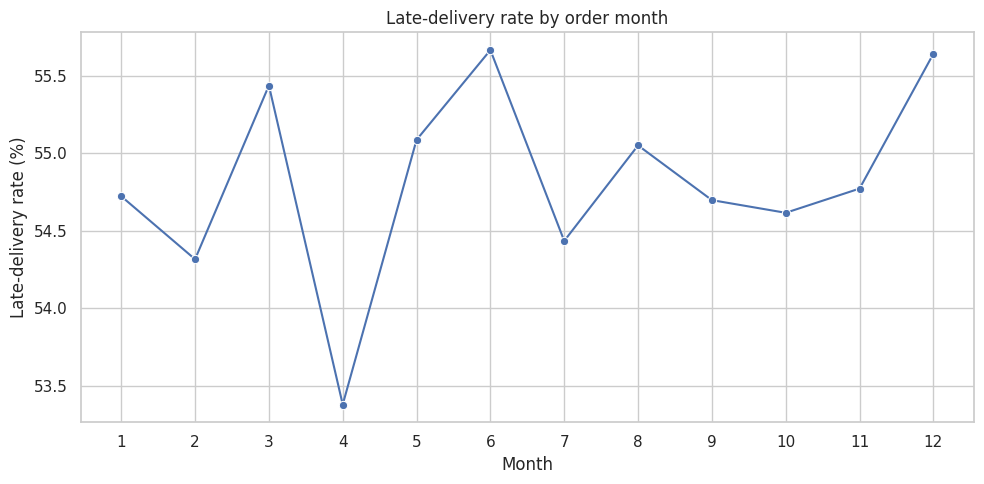

In [31]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly_summary,
    x="order_month",
    y="late_rate_percentage",
    marker="o"
)

plt.title("Late-delivery rate by order month")
plt.xlabel("Month")
plt.ylabel("Late-delivery rate (%)")
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

Defining Numerical Columns

In [32]:
numerical_columns = [
    "scheduled_shipping_days",
    "total_quantity",
    "gross_sales",
    "total_order_value",
    "total_discount",
    "total_profit",
    "item_rows",
    "unique_products",
    "unique_categories",
    "order_year",
    "order_month",
    "order_day_of_week",
    "order_hour",
    "is_weekend"
]

display(
    train_eda[numerical_columns]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
scheduled_shipping_days,"46,026.000",2.939,1.372,0.000,2.000,4.000,4.000,4.000
total_quantity,"46,026.000",5.841,4.172,1.000,2.000,5.000,9.000,24.000
gross_sales,"46,026.000",559.858,356.098,9.990,269.920,499.980,799.960,"3,449.910"
total_order_value,"46,026.000",502.948,321.410,7.490,244.203,455.640,721.243,"2,768.410"
total_discount,"46,026.000",56.911,46.763,0.000,20.000,47.600,82.543,681.500
total_profit,"46,026.000",60.237,189.372,"-3,442.500",7.750,72.775,158.877,980.280
item_rows,"46,026.000",2.747,1.479,1.000,1.000,3.000,4.000,5.000
unique_products,"46,026.000",2.429,1.256,1.000,1.000,2.000,3.000,5.000
unique_categories,"46,026.000",2.426,1.253,1.000,1.000,2.000,3.000,5.000
order_year,"46,026.000","2,016.078",0.879,"2,015.000","2,015.000","2,016.000","2,017.000","2,018.000"


Numerical histograms

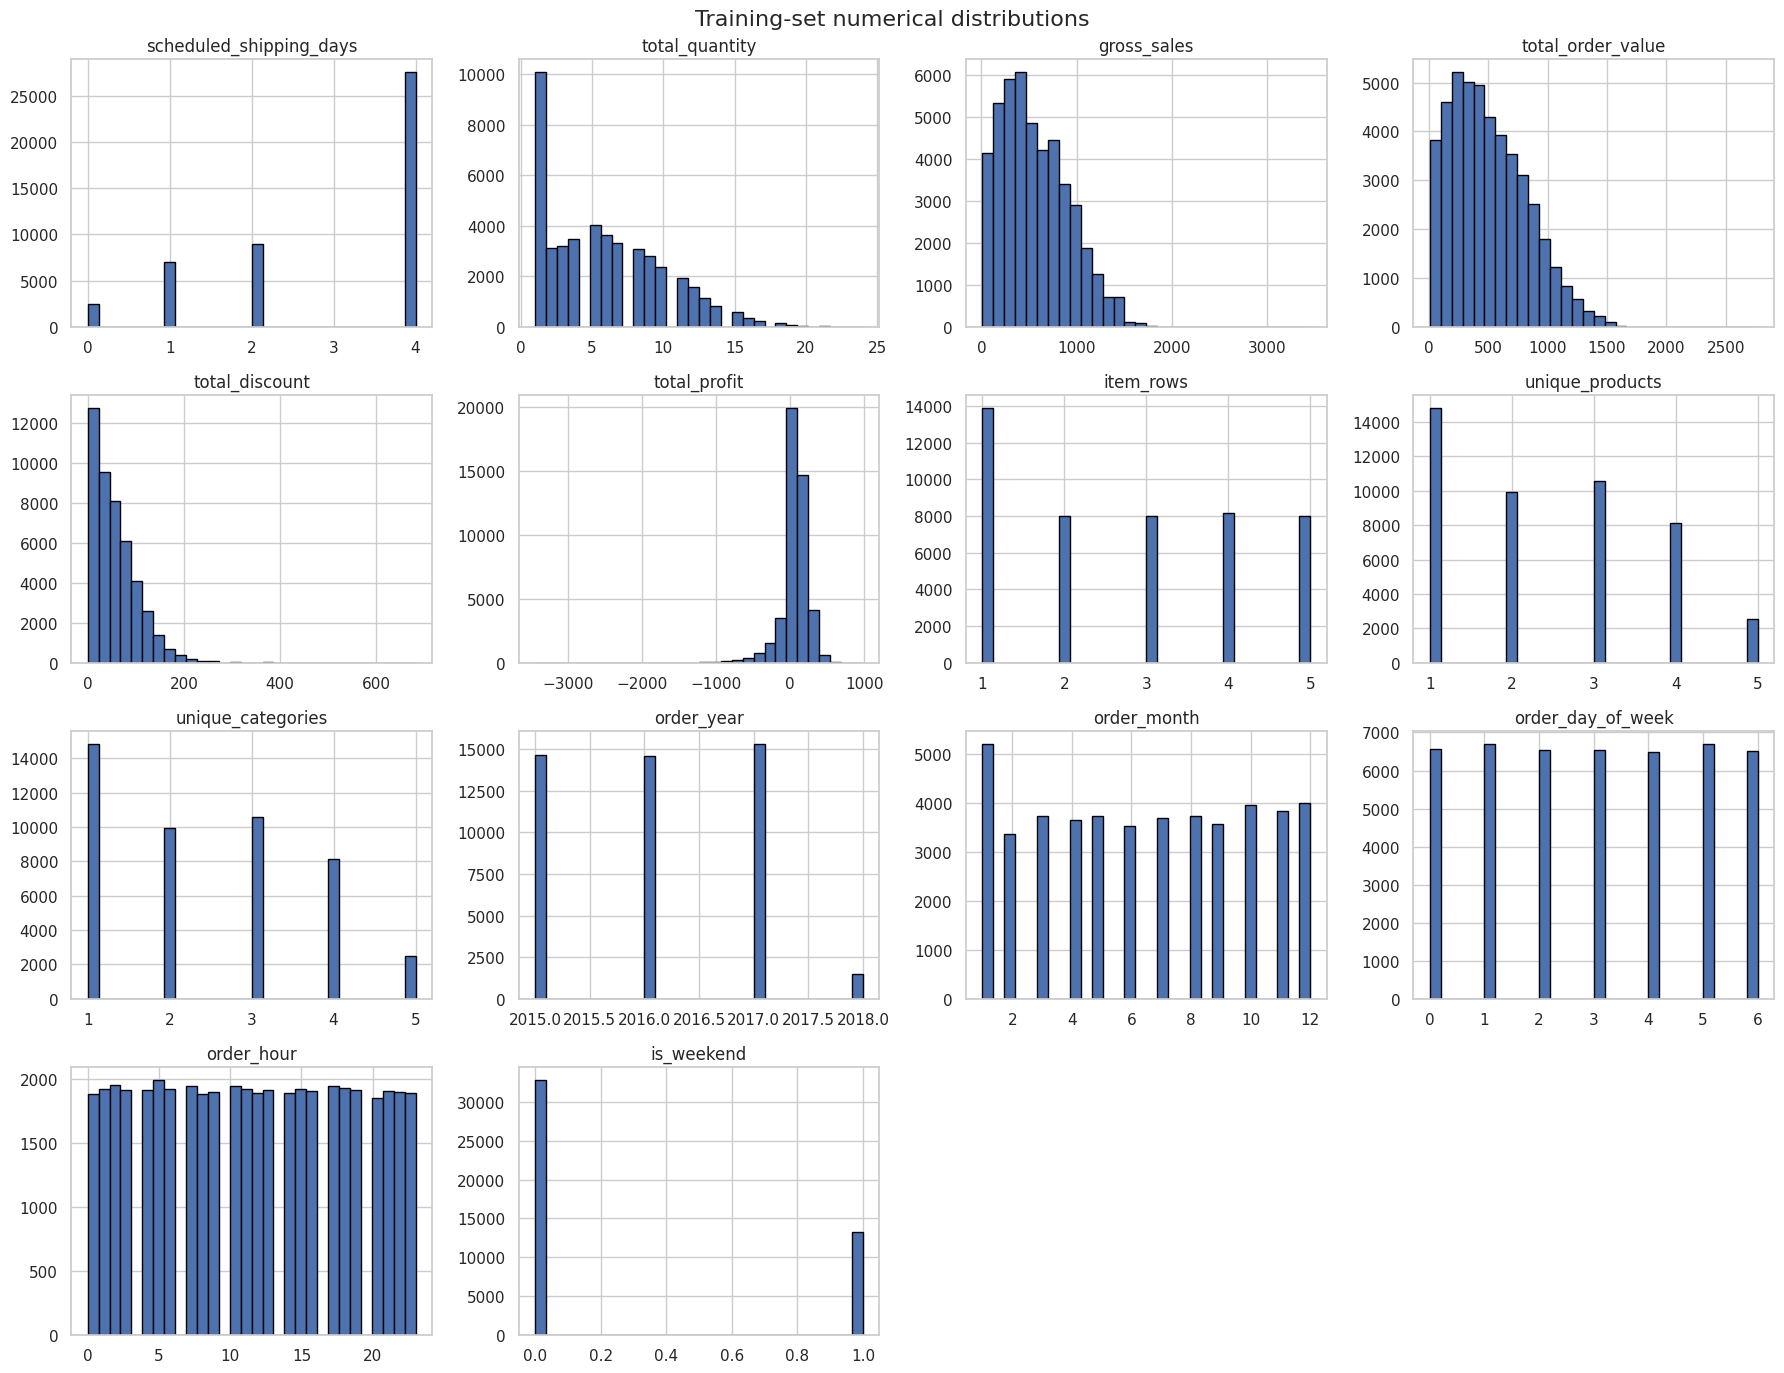

In [33]:
train_eda[numerical_columns].hist(
    figsize=(18, 14),
    bins=30,
    edgecolor="black"
)

plt.suptitle(
    "Training-set numerical distributions",
    fontsize=16
)

plt.tight_layout()
plt.show()

Numerical boxplots

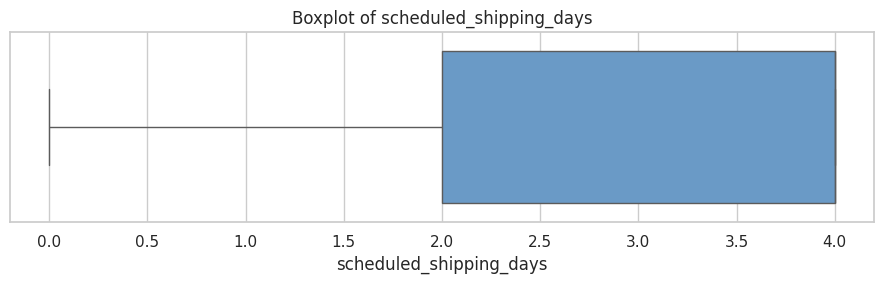

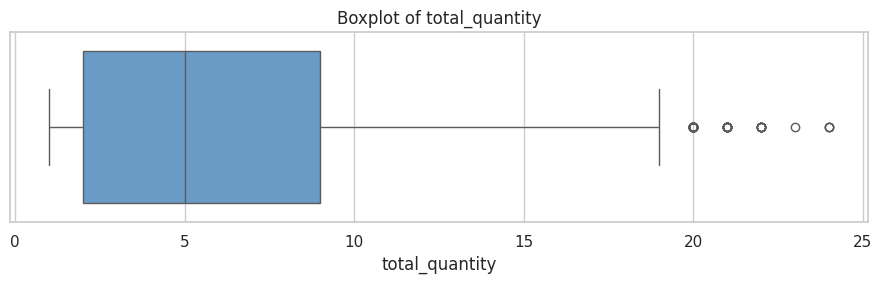

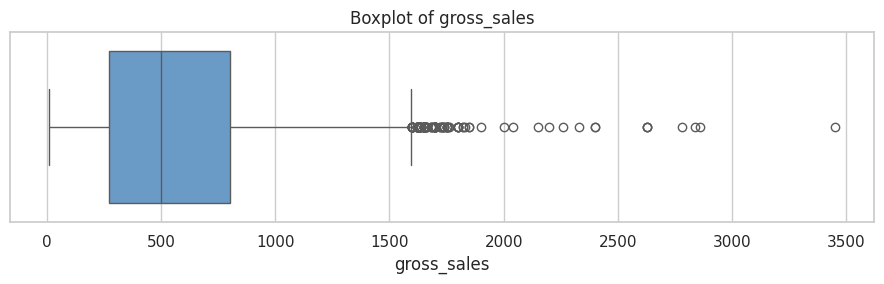

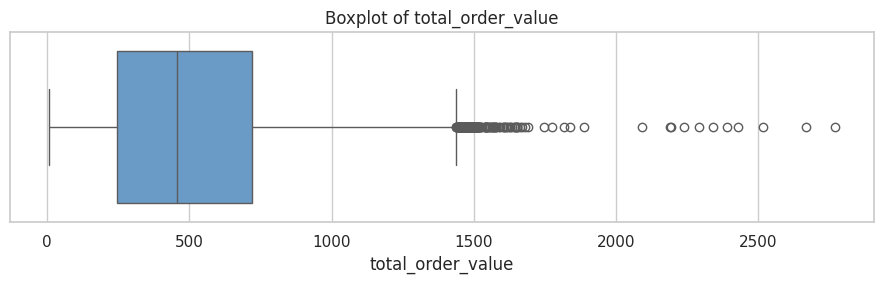

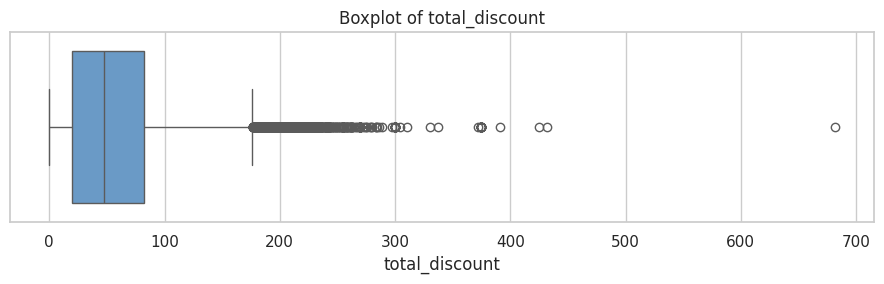

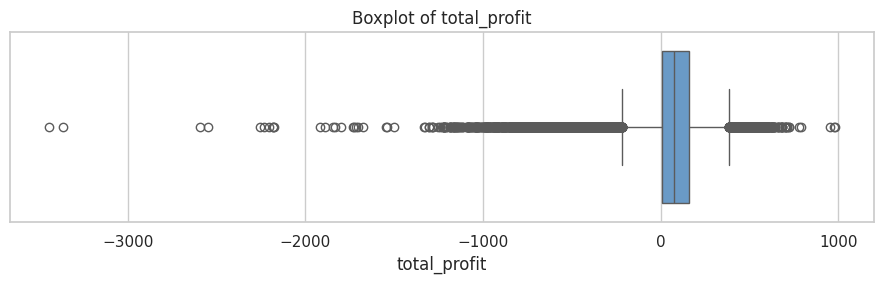

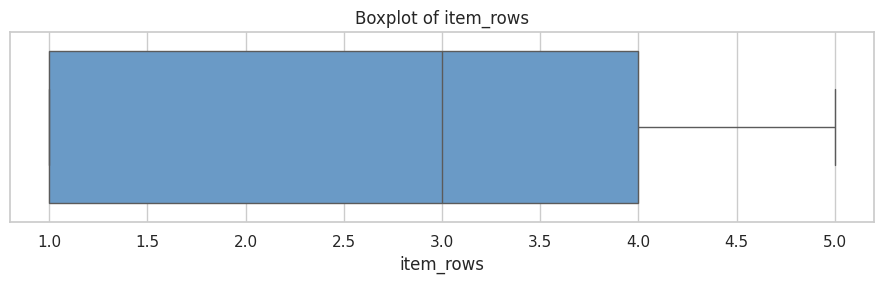

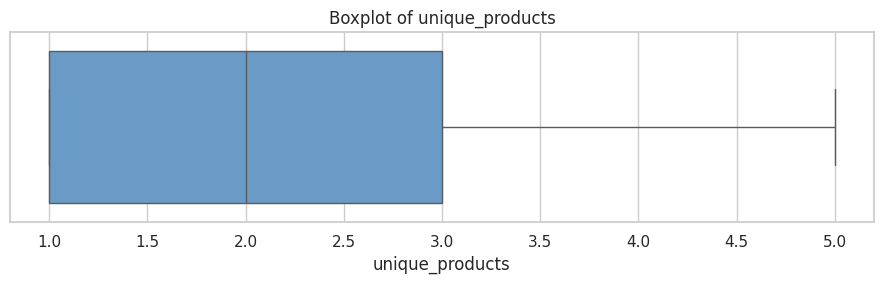

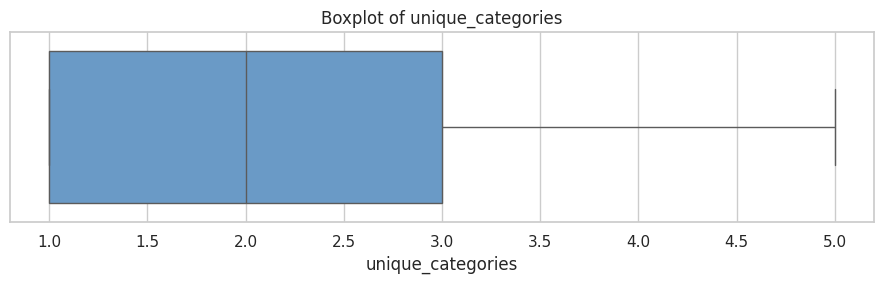

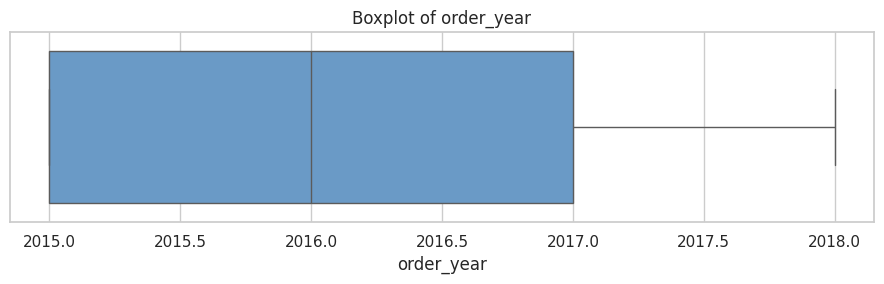

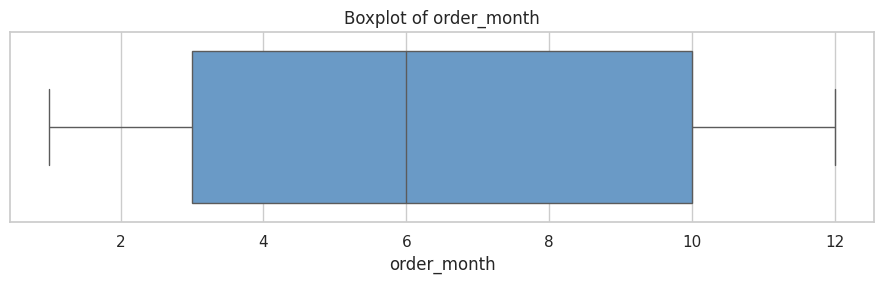

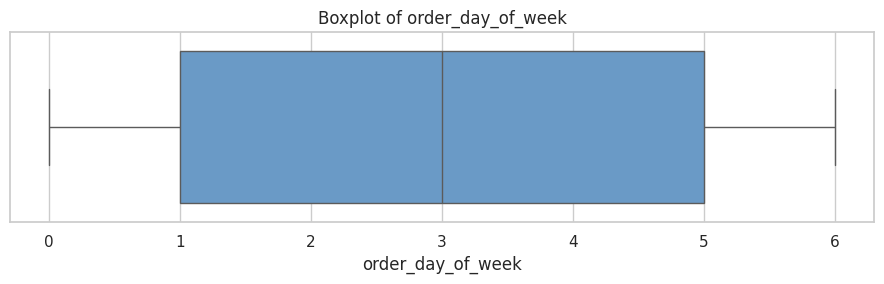

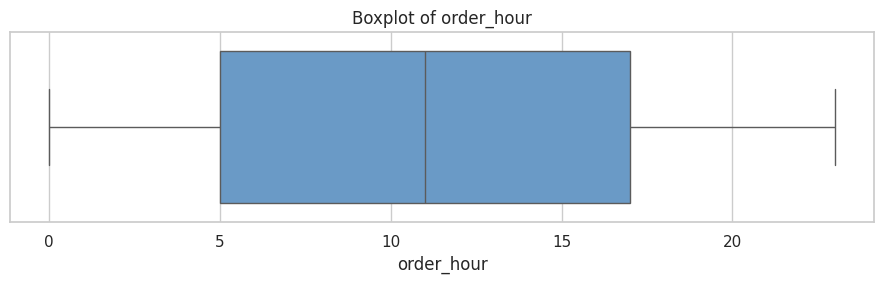

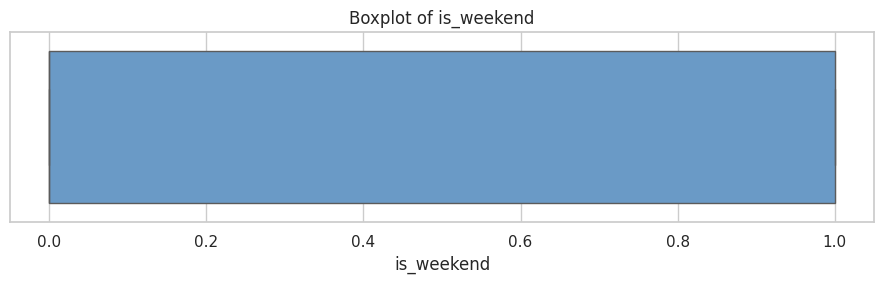

In [34]:
for column in numerical_columns:
    plt.figure(figsize=(9, 3))

    sns.boxplot(
        data=train_eda,
        x=column,
        color="#5B9BD5"
    )

    plt.title(f"Boxplot of {column}")

    plt.tight_layout()
    plt.show()

IQR outlier function

In [35]:
def create_iqr_outlier_report(
    dataframe,
    columns
):
    results = []

    for column in columns:
        values = dataframe[column].dropna()

        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1

        lower_limit = q1 - 1.5 * iqr
        upper_limit = q3 + 1.5 * iqr

        outlier_mask = (
            (values < lower_limit)
            | (values > upper_limit)
        )

        outlier_count = outlier_mask.sum()

        results.append({
            "column": column,
            "q1": q1,
            "q3": q3,
            "lower_limit": lower_limit,
            "upper_limit": upper_limit,
            "outlier_count": outlier_count,
            "outlier_percentage": (
                outlier_count
                / len(values)
                * 100
            )
        })

    return pd.DataFrame(results)

IQR outlier report

In [36]:
outlier_report = create_iqr_outlier_report(
    train_eda,
    numerical_columns
)

outlier_report = (
    outlier_report
    .sort_values(
        "outlier_percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

display(outlier_report)

,column,q1,q3,lower_limit,upper_limit,outlier_count,outlier_percentage
0,total_profit,7.750,158.877,-218.941,385.569,3625,7.876
1,total_discount,20.000,82.543,-73.814,176.356,950,2.064
2,total_order_value,244.203,721.243,-471.358,"1,436.803",224,0.487
3,gross_sales,269.920,799.960,-525.140,"1,595.020",139,0.302
4,total_quantity,2.000,9.000,-8.500,19.500,70,0.152
5,scheduled_shipping_days,2.000,4.000,-1.000,7.000,0,0.000
6,item_rows,1.000,4.000,-3.500,8.500,0,0.000
7,unique_products,1.000,3.000,-2.000,6.000,0,0.000
8,unique_categories,1.000,3.000,-2.000,6.000,0,0.000
9,order_year,"2,015.000","2,017.000","2,012.000","2,020.000",0,0.000


Categorical audit

In [37]:
categorical_columns = [
    "shipping_mode",
    "payment_type",
    "customer_segment",
    "market",
    "order_region",
    "order_country",
    "order_state"
]

categorical_report = pd.DataFrame({
    "column": categorical_columns,

    "unique_values": [
        train_eda[column].nunique(
            dropna=False
        )
        for column in categorical_columns
    ],

    "missing_values": [
        train_eda[column].isna().sum()
        for column in categorical_columns
    ]
})

categorical_report = (
    categorical_report
    .sort_values(
        "unique_values",
        ascending=False
    )
    .reset_index(drop=True)
)

display(categorical_report)

,column,unique_values,missing_values
0,order_state,1061,0
1,order_country,159,0
2,order_region,23,0
3,market,5,0
4,shipping_mode,4,0
5,payment_type,4,0
6,customer_segment,3,0


Rare-category report

In [38]:
def create_rare_category_report(
    dataframe,
    columns,
    threshold_percentage=1.0
):
    results = []

    for column in columns:
        category_percentages = (
            dataframe[column]
            .value_counts(
                normalize=True,
                dropna=False
            )
            .mul(100)
        )

        rare_categories = (
            category_percentages[
                category_percentages
                < threshold_percentage
            ]
        )

        results.append({
            "column": column,
            "total_categories":
                len(category_percentages),

            "rare_categories_below_1_percent":
                len(rare_categories),

            "smallest_category_percentage":
                category_percentages.min()
        })

    return pd.DataFrame(results)

In [39]:
rare_category_report = (
    create_rare_category_report(
        train_eda,
        categorical_columns,
        threshold_percentage=1.0
    )
)

display(rare_category_report)

,column,total_categories,rare_categories_below_1_percent,smallest_category_percentage
0,shipping_mode,4,0,5.314
1,payment_type,4,0,11.102
2,customer_segment,3,0,18.164
3,market,5,0,5.829
4,order_region,23,5,0.254
5,order_country,159,136,0.002
6,order_state,1061,1046,0.002


In [40]:
def create_saved_split(
    X_part,
    y_part,
    orders_dataframe
):
    saved_split = X_part.copy()

    saved_split.insert(
        0,
        "Order Id",
        orders_dataframe.loc[
            saved_split.index,
            "Order Id"
        ].to_numpy()
    )

    saved_split["target"] = (
        y_part.to_numpy()
    )

    return saved_split.reset_index(
        drop=True
    )

In [41]:
train_dataset = create_saved_split(
    X_train,
    y_train,
    orders
)

validation_dataset = create_saved_split(
    X_validation,
    y_validation,
    orders
)

test_dataset = create_saved_split(
    X_test,
    y_test,
    orders
)

print("Training dataset:", train_dataset.shape)
print("Validation dataset:", validation_dataset.shape)
print("Testing dataset:", test_dataset.shape)

Training dataset: (46026, 23)
Validation dataset: (9863, 23)
Testing dataset: (9863, 23)


Split Integrity check

In [42]:
train_ids = set(
    train_dataset["Order Id"]
)

validation_ids = set(
    validation_dataset["Order Id"]
)

test_ids = set(
    test_dataset["Order Id"]
)

assert train_ids.isdisjoint(
    validation_ids
)

assert train_ids.isdisjoint(
    test_ids
)

assert validation_ids.isdisjoint(
    test_ids
)

assert (
    len(train_dataset)
    + len(validation_dataset)
    + len(test_dataset)
    == len(orders)
)

assert (
    train_dataset["Order Id"].nunique()
    == len(train_dataset)
)

assert (
    validation_dataset["Order Id"].nunique()
    == len(validation_dataset)
)

assert (
    test_dataset["Order Id"].nunique()
    == len(test_dataset)
)

print("Split integrity checks passed.")

Split integrity checks passed.


In [ ]:
Creating Drive Folders

In [43]:
PROJECT_OUTPUT_FOLDER = Path(
    "/content/drive/MyDrive/"
    "HeadsUpProject/outputs"
)

SPLIT_FOLDER = (
    PROJECT_OUTPUT_FOLDER / "splits"
)

REPORT_FOLDER = (
    PROJECT_OUTPUT_FOLDER / "eda_reports"
)

SPLIT_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)

REPORT_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)

print("Output folders created.")

Output folders created.


In [44]:
train_dataset.to_csv(
    SPLIT_FOLDER / "train_orders.csv",
    index=False
)

validation_dataset.to_csv(
    SPLIT_FOLDER / "validation_orders.csv",
    index=False
)

test_dataset.to_csv(
    SPLIT_FOLDER / "test_orders.csv",
    index=False
)

print("Split datasets saved successfully.")

Split datasets saved successfully.


In [45]:
orders.to_csv(
    REPORT_FOLDER
    / "orders_aggregated.csv",
    index=False
)

dataset_summary.to_csv(
    REPORT_FOLDER
    / "dataset_summary.csv",
    index=False
)

schema_report.to_csv(
    REPORT_FOLDER
    / "schema_report.csv",
    index=False
)

missing_report.to_csv(
    REPORT_FOLDER
    / "raw_missing_value_report.csv",
    index=False
)

consistency_report.to_csv(
    REPORT_FOLDER
    / "order_consistency_report.csv",
    index=False
)

split_report.to_csv(
    REPORT_FOLDER
    / "split_report.csv",
    index=False
)

outlier_report.to_csv(
    REPORT_FOLDER
    / "training_outlier_report.csv",
    index=False
)

categorical_report.to_csv(
    REPORT_FOLDER
    / "training_categorical_report.csv",
    index=False
)

rare_category_report.to_csv(
    REPORT_FOLDER
    / "training_rare_category_report.csv",
    index=False
)

print("EDA reports saved successfully.")

EDA reports saved successfully.


In [46]:
print("Saved split files:")

for file in sorted(
    SPLIT_FOLDER.glob("*.csv")
):
    size_mb = (
        file.stat().st_size
        / (1024 * 1024)
    )

    print(
        f"{file.name}: "
        f"{size_mb:.2f} MB"
    )

Saved split files:
test_orders.csv: 1.47 MB
train_orders.csv: 6.85 MB
validation_orders.csv: 1.47 MB


In [47]:
saved_train = pd.read_csv(
    SPLIT_FOLDER / "train_orders.csv"
)

saved_validation = pd.read_csv(
    SPLIT_FOLDER
    / "validation_orders.csv"
)

saved_test = pd.read_csv(
    SPLIT_FOLDER / "test_orders.csv"
)

print(
    "Reloaded training:",
    saved_train.shape
)

print(
    "Reloaded validation:",
    saved_validation.shape
)

print(
    "Reloaded testing:",
    saved_test.shape
)

assert len(saved_train) == len(train_dataset)
assert len(saved_validation) == len(validation_dataset)
assert len(saved_test) == len(test_dataset)

print("Saved-file verification passed.")

Reloaded training: (46026, 23)
Reloaded validation: (9863, 23)
Reloaded testing: (9863, 23)
Saved-file verification passed.


## EDA Summary

- The raw dataset contains 180,519 order-item rows and 53 columns.
- The modelling unit is an order identified by `Order Id`.
- Aggregation produced 65,752 unique order-level observations.
- No exact duplicate raw rows were identified.
- Missing values are concentrated in `Product Description` and
  `Order Zipcode`. These columns were not retained in the order-level
  modelling dataset.
- The supplied target is reasonably balanced, with approximately
  54.8% late-delivery cases.
- The existing `Late_delivery_risk` column assigns late deliveries to
  class 1 but assigns cancelled shipments to class 0. This differs from
  the wording in the proposal and requires a documented team decision.
- Shipping mode has a substantial relationship with historical
  late-delivery rates.
- Potential outliers are concentrated in profit, discount and order-value
  variables. They were identified but not automatically removed.
- The order-level dataset was divided into stratified training,
  validation and test sets using a 70/15/15 split.
- Model-guiding EDA was performed using the training set.
- Preprocessing parameters must be fitted using the training data only
  and then applied unchanged to validation and test data.